In [1]:
import pandas as pd

In [41]:
hotels = pd.read_csv('data/hotels.csv')
hotels.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [42]:
# ПОДГОТОВКА ДАННЫХ ПЕРЕД РАЗБИЕНИЕМ НА TRAIN/TEST

# 1. Удаляем все строковые столбцы (object)
object_columns = hotels.select_dtypes(include=['object']).columns
hotels_clean = hotels.drop(columns=object_columns)

# 2. Заполняем пропуски нулями
hotels_clean = hotels_clean.fillna(0)

# 3. Проверяем результат
print(f"Было: {len(hotels.columns)}")
print(f"Стало: {len(hotels_clean.columns)}")
print(f"Строки {hotels_clean.select_dtypes(include=['object']).columns.tolist()}")
print(f"Пропуски {hotels_clean.isnull().sum().sum()}")

Было: 17
Стало: 9
Строки []
Пропуски 0


In [43]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels_clean.drop(['reviewer_score'], axis=1)
y = hotels_clean['reviewer_score']

In [44]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [45]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [46]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  


In [47]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.14131681267578933


Небольшой бонус:


In [10]:
# # убираем признаки которые еще не успели обработать, 
# # модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
# object_columns = [s for s in hotels.columns if hotels[s].dtypes == 'object']
# hotels.drop(object_columns, axis = 1, inplace=True)

# # заполняем пропуски самым простым способом
# hotels = hotels.fillna(0)

In [49]:
# непрерывные признаки
num_cols = [
    'additional_number_of_scoring',
    'average_score',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'lat',
    'lng'
]


# категориальные признаки
cat_cols = ['average_score', 'lat', ...]

reviewer_nationality_encoded    35453.351308
dtype: float64


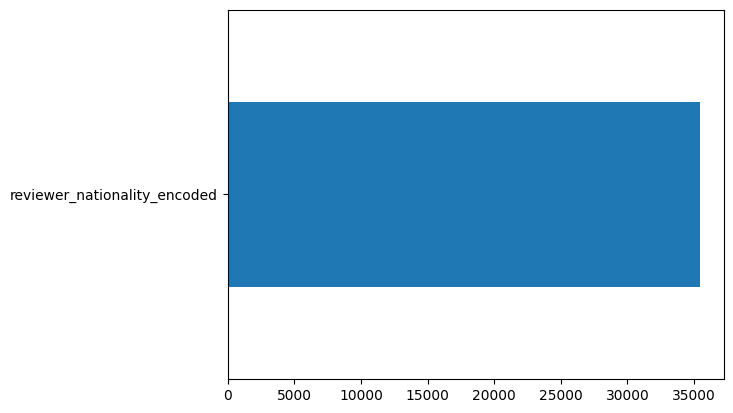

In [50]:
# Преобразуем целевую переменную в int
y = y.astype('int')

# Категориальные признаки (только те, что уже в числах)

from sklearn.preprocessing import LabelEncoder

# Кодируем национальность рецензента
le = LabelEncoder()
hotels['reviewer_nationality_encoded'] = le.fit_transform(hotels['reviewer_nationality'].fillna('Unknown'))


cat_cols = ['reviewer_nationality_encoded']

from sklearn.feature_selection import chi2

# Временный X только с категориальными признаками
X_cat = hotels[cat_cols].fillna(0)

imp_cat = pd.Series(chi2(X_cat, y)[0], index=cat_cols)
imp_cat.sort_values(inplace=True)
imp_cat.plot(kind='barh')
print(imp_cat)

<Axes: >

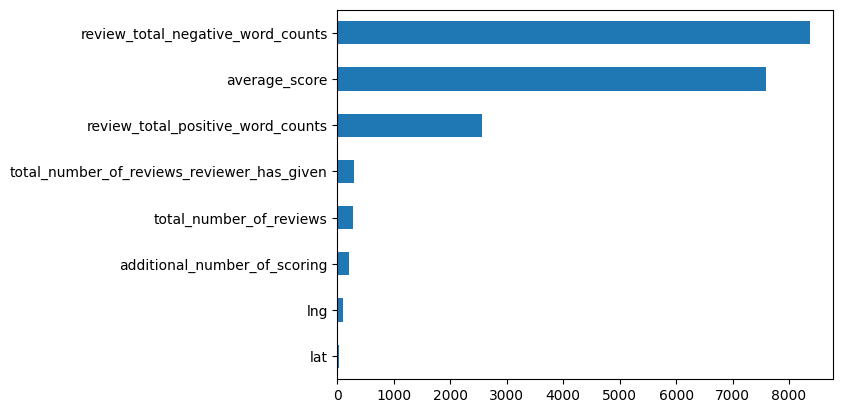

In [51]:
from sklearn.feature_selection import f_classif # anova

imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

In [52]:
unique_hotels = hotels['hotel_name'].nunique()
print(f"Количество уникальных названий отелей: {unique_hotels}")

Количество уникальных названий отелей: 1492


In [53]:
# Преобразуем в datetime
hotels['review_date'] = pd.to_datetime(hotels['review_date'])

# Последний отзыв (максимальная дата)
latest_review = hotels['review_date'].max()
print(f"Последний отзыв: {latest_review.strftime('%Y-%m-%d')}")

# Первый отзыв (минимальная дата)
earliest_review = hotels['review_date'].min()
print(f"Первый отзыв: {earliest_review.strftime('%Y-%m-%d')}")

Последний отзыв: 2017-08-03
Первый отзыв: 2015-08-04


In [54]:
import re

# Извлекаем все теги через регулярное выражение
all_tags_str = ' '.join(hotels['tags'].dropna().astype(str))
tags_found = re.findall(r"'([^']*)'", all_tags_str)
tags_clean = [tag.strip() for tag in tags_found]

unique_tags_count = len(set(tags_clean))
print(f"Количество уникальных тегов: {unique_tags_count}")

Количество уникальных тегов: 2368


In [55]:
from collections import Counter

# Извлекаем все теги через регулярное выражение
all_tags_str = ' '.join(hotels['tags'].dropna().astype(str))
tags_found = re.findall(r"'([^']*)'", all_tags_str)
tags_clean = [tag.strip() for tag in tags_found]

# Подсчитываем частоту
tag_counts = Counter(tags_clean)
most_common_tag, most_common_count = tag_counts.most_common(1)[0]

print(f"Самый популярный тег: '{most_common_tag}'")
print(f"Количество упоминаний: {most_common_count}")

Самый популярный тег: 'Leisure trip'
Количество упоминаний: 313593


In [56]:
# Собираем все теги в одну строку
all_tags_str = ' '.join(hotels['tags'].dropna().astype(str))

# Ищем все упоминания "Stayed X nights"
nights_found = re.findall(r"Stayed (\d+) nights?", all_tags_str, re.IGNORECASE)
nights_int = [int(n) for n in nights_found]

# Подсчитываем частоту
nights_counter = Counter(nights_int)
most_common_nights, count = nights_counter.most_common(1)[0]

print(f"Чаще всего останавливаются на {most_common_nights} ночь(и)")

print("\nРаспределение продолжительностей:")
for nights, cnt in sorted(nights_counter.items()):
    print(f"  {nights} ночь(и): {cnt} раз(а)")

Чаще всего останавливаются на 1 ночь(и)

Распределение продолжительностей:
  1 ночь(и): 145373 раз(а)
  2 ночь(и): 100263 раз(а)
  3 ночь(и): 72000 раз(а)
  4 ночь(и): 35748 раз(а)
  5 ночь(и): 15611 раз(а)
  6 ночь(и): 7399 раз(а)
  7 ночь(и): 5549 раз(а)
  8 ночь(и): 1910 раз(а)
  9 ночь(и): 966 раз(а)
  10 ночь(и): 663 раз(а)
  11 ночь(и): 306 раз(а)
  12 ночь(и): 217 раз(а)
  13 ночь(и): 174 раз(а)
  14 ночь(и): 184 раз(а)
  15 ночь(и): 87 раз(а)
  16 ночь(и): 38 раз(а)
  17 ночь(и): 27 раз(а)
  18 ночь(и): 24 раз(а)
  19 ночь(и): 23 раз(а)
  20 ночь(и): 17 раз(а)
  21 ночь(и): 19 раз(а)
  22 ночь(и): 8 раз(а)
  23 ночь(и): 6 раз(а)
  24 ночь(и): 5 раз(а)
  25 ночь(и): 4 раз(а)
  26 ночь(и): 6 раз(а)
  27 ночь(и): 10 раз(а)
  28 ночь(и): 7 раз(а)
  29 ночь(и): 3 раз(а)
  30 ночь(и): 10 раз(а)


In [57]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.4f}")

MAPE: 0.1413


In [61]:
sample_sub = pd.read_csv('data/sample_submission.csv')
print(sample_sub.head())
print(sample_sub.columns.tolist())

   reviewer_score      id
0               1  488440
1              10  274649
2               3  374688
3              10  404352
4               9  451596
['reviewer_score', 'id']


In [ ]:

# ПРАВИЛЬНЫЙ САБМИТ

# 1. Загружаем sample submission, чтобы получить правильные ID
sample_sub = pd.read_csv('data/sample_submission.csv')
print(f"Ожидаемое количество строк для сабмита: {len(sample_sub)}")

# 2. Загружаем и обрабатываем тестовые данные
test = pd.read_csv('data/hotels_test.csv')

# 3. Применяем ТЕ ЖЕ САМЫЕ преобразования, что и к тренировочным данным
# Удаляем строковые колонки (object)
object_columns = test.select_dtypes(include=['object']).columns
test_clean = test.drop(columns=object_columns)

# Заполняем пропуски нулями
test_clean = test_clean.fillna(0)

# 4. Убеждаемся, что колонки соответствуют X_train
for col in X_train.columns:
    if col not in test_clean.columns:
        test_clean[col] = 0

# Оставляем только те колонки, которые были в X_train
test_clean = test_clean[X_train.columns]

print(f"Строк в тестовых данных после обработки: {len(test_clean)}")

# 5. Делаем предсказания
test_pred = regr.predict(test_clean)

# 6. Создаём файл для сабмита
submission = pd.DataFrame({
    'reviewer_score': test_pred,  # Сначала reviewer_score
    'id': sample_sub['id']         # Потом id из sample_sub
})

# 7. Проверяем результат
print(f"\nПервые 5 строк submission:")
print(submission.head())
print(f"\nРазмер submission: {len(submission)} строк")

# 8. Сохраняем файл
submission.to_csv('submission.csv', index=False)
print("\nФайл создан")

Ожидаемое количество строк для сабмита: 128935
Строк в тестовых данных после обработки: 128935

Первые 5 строк submission:
   reviewer_score      id
0        8.546000  488440
1        7.580000  274649
2        8.304000  374688
3        9.573000  404352
4        9.364933  451596

Размер submission: 128935 строк

Файл создан
